# 📊 Fraud Detection using Variance, Covariance, IQR & Z-Score

### Industry Scenario
We simulate **credit card transactions** and detect anomalies (fraud-like behavior).

This notebook demonstrates:
- Variance → data spread
- Covariance → relationships
- IQR → robust outlier detection
- Z-score → statistical anomaly detection


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 🔹 Generate Transaction Data

In [8]:
# Normal transactions
amount = np.random.normal(500, 50, 1000)
risk_score = amount * 0.01 + np.random.normal(0, 0.5, 1000)

# Inject anomalies
amount = np.append(amount, [1200, 1500, 50])
risk_score = np.append(risk_score, [15, 18, 0.1])

df = pd.DataFrame({"amount": amount, "risk_score": risk_score})
df.head(2)

,amount,risk_score
0,466.241086,3.708507
1,492.774066,4.497548


## 🔹 Variance

In [3]:
print("Variance (Amount):", np.var(df['amount']))

Variance (Amount): 4071.0849085215505


## 🔹 Covariance

In [4]:
cov_matrix = np.cov(df['amount'], df['risk_score'])
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[4.07514787e+03 4.49811049e+01]
 [4.49811049e+01 7.57793010e-01]]


## 🔹 IQR Method

In [5]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df[(df['amount'] < lower) | (df['amount'] > upper)]
print(iqr_outliers)

           amount  risk_score
74     369.012745    4.188261
179    636.008458    5.808290
209    692.636575    7.801154
262    337.936633    3.648744
478    653.944040    6.095694
646    365.155668    3.557985
668    367.451510    4.094825
755    631.619103    7.003020
1000  1200.000000   15.000000
1001  1500.000000   18.000000
1002    50.000000    0.100000


## 🔹 Z-Score Method

In [6]:
mean = df['amount'].mean()
std = df['amount'].std()

df['z_score'] = (df['amount'] - mean) / std
z_outliers = df[np.abs(df['z_score']) > 3]

print(z_outliers)

      amount  risk_score    z_score
1000  1200.0        15.0  10.930828
1001  1500.0        18.0  15.630306
1002    50.0         0.1  -7.083835


## 🔹 Visualization

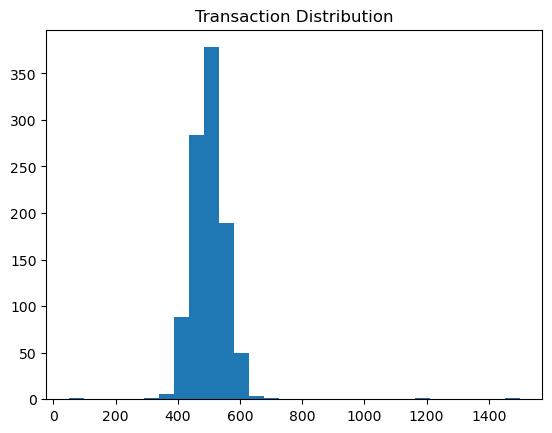

In [7]:
plt.hist(df['amount'], bins=30)
plt.title("Transaction Distribution")
plt.show()

## ✅ Conclusion
- IQR works better for skewed data
- Z-score works better for normal distributions
- Understanding data is key before ML modeling
